In [1]:
# imports and parameter
import glob
from pathlib import Path
import re
import math
import datetime
import pandas as pd
import seaborn as sns
from matplotlib.ticker import FuncFormatter
import matplotlib.pyplot as plt

In [2]:
# helper function to convert bytes to human readable format
def get_mem_str(num):
    for unit in ("", "KiB", "MiB", "GiB"):
        if num < 1024.0:
            return f"{num:3.1f} {unit}"
        num /= 1024.0
    return "too big"

In [3]:
# function to read in lean miner results
def read_base(filename):
    item = { "Timings" : [], "Type" : "base" }
    with open(filename) as file:
        for line in file:
            m = re.match('Looking for ([0-9]+)-cycle on cuckatoo([0-9]+)\\("([0-9a-fA-F]*)",([0-9]+)-([0-9]+)\\).*([0-9]+) threads', line)
            if m:
                item.update({ "ProofSize" : int(m.group(1)), "EdgeBits" : int(m.group(2)), "Seed" : m.group(3), "NonceStart" : int(m.group(4)), "NonceStop" : int(m.group(5)) , "Threads" : int(m.group(6)) } )
            k = re.match('Time: ([0-9]+) ms.*', line)
            if k:
                item["Timings"].append(float(k.group(1))/1000)
        item["Filename"] = filename
    item["MemoryBits"] = 2**(item["EdgeBits"]+1)
    item["Nonces"] = item["NonceStop"] - item["NonceStart"] + 1
    if item["Nonces"] != len(item["Timings"]):
        print('Warning: Timings and Nonces are not matched in file "%s"!' % filename)
    return item

# function to read in splean miner results
def read_eval(filename):
    item = { "Timings" : [], "Panics" : 0, "Type" : "eval" }
    with open(filename) as file:
        for line in file:
            m = re.match('Looking for ([0-9]+)-cycle on cuckatoo([0-9]+)\\("([0-9a-fA-F]*)",([0-9]+)-([0-9]+)\\).*([0-9]+) threads', line)
            if m:
                item.update({ "ProofSize" : int(m.group(1)), "EdgeBits" : int(m.group(2)), "Seed" : m.group(3), "NonceStart" : int(m.group(4)), "NonceStop" : int(m.group(5)) , "Threads" : int(m.group(6)) } )
            k = re.match('Time: (([0-9]*[.])?[0-9]+) ms', line)
            if k:
                item["Timings"].append(float(k.group(1))/1000)
            l = re.match('Using ([0-9]+) bits \\(.*\\) of max. memory \\(.* batch size: ([0-9]+), batches: ([0-9]+)\\)', line)
            if l:
                item.update({ "MemoryBits" : int(l.group(1)), "BatchSize" : int(l.group(2)), "Batches" : int(l.group(3)) })
            n = re.match('PANIC:', line)
            if n:
                item["Panics"] += 1
        item["Filename"] = filename
    item["Nonces"] = item["NonceStop"] - item["NonceStart"] + 1
    if item["Nonces"] != len(item["Timings"]):
        print('Warning: Timings and Nonces are not matched in file "%s"!' % filename)
    item["kFactor"] = int(math.log2(2**item["EdgeBits"]/(item["BatchSize"])))
    item["Attempts"] = 1.0/(1.0-((1.0-(item["BatchSize"]*item["Batches"])/(2**item["EdgeBits"]))**item["ProofSize"]))
    if(item["Panics"]>0):
        print('Warning: Panics found in file "%s"!' % filename)
    return item

In [4]:
# read in all data files
base_data = [read_base(f) for f in glob.glob("../eval/data/lean*.out")] #baseline data from lean miner
eval_data = [read_eval(f) for f in glob.glob("../eval/data/splean*.out")] #evaluation data from splean miner
#eval_data = []
#for f in glob.glob("data/splean27*.out"):
#    eval_data.append(read_eval(f)) #evaluation data from splean miner
#for f in glob.glob("data/splean29*.out"):
#    eval_data.append(read_eval(f)) #evaluation data from splean miner   
#for f in glob.glob("data/splean31x8_k9*.out"):
#    eval_data.append(read_eval(f)) #evaluation data from splean miner
#for f in glob.glob("data/splean31x8_k10*.out"):
#    eval_data.append(read_eval(f)) #evaluation data from splean 
#for f in glob.glob("data/splean31x8_k11*.out"):
#    eval_data.append(read_eval(f)) #evaluation data from splean miner
#for f in glob.glob("test_k*.out"):
#    eval_data.append(read_eval(f)) #evaluation data from splean miner

In [5]:
# load data into Pandas dataframe
base_df = pd.DataFrame(base_data).explode('Timings')
eval_df = pd.DataFrame(eval_data).explode('Timings')

eval_df

,Timings,Panics,Type,ProofSize,EdgeBits,Seed,NonceStart,NonceStop,Threads,MemoryBits,BatchSize,Batches,Filename,Nonces,kFactor,Attempts
0,171.99336,0,eval,42,27,00000000005eed20000000000000000000000000000000...,0,3,1,3498880,32768,4,../eval/data/splean27x8_k12_t1_seed2.out,4,12,24.872465
0,174.20545,0,eval,42,27,00000000005eed20000000000000000000000000000000...,0,3,1,3498880,32768,4,../eval/data/splean27x8_k12_t1_seed2.out,4,12,24.872465
0,179.06895,0,eval,42,27,00000000005eed20000000000000000000000000000000...,0,3,1,3498880,32768,4,../eval/data/splean27x8_k12_t1_seed2.out,4,12,24.872465
0,178.44098,0,eval,42,27,00000000005eed20000000000000000000000000000000...,0,3,1,3498880,32768,4,../eval/data/splean27x8_k12_t1_seed2.out,4,12,24.872465
1,45.98212,0,eval,42,27,000005eed1000000000000000000000000000000000000...,0,3,8,3507968,32768,4,../eval/data/splean27x8_k12_t8_seed1.out,4,12,24.872465
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
138,75.91757,0,eval,42,27,00000000005eed20000000000000000000000000000000...,0,3,2,902144,8192,4,../eval/data/splean27x8_k14_t2_seed2.out,4,14,98.012759
139,237.71394,0,eval,42,29,000005eed1000000000000000000000000000000000000...,0,3,4,27657472,262144,4,../eval/data/splean29x8_k11_t4_seed1.out,4,11,12.685409
139,240.39751,0,eval,42,29,000005eed1000000000000000000000000000000000000...,0,3,4,27657472,262144,4,../eval/data/splean29x8_k11_t4_seed1.out,4,11,12.685409
139,238.96612,0,eval,42,29,000005eed1000000000000000000000000000000000000...,0,3,4,27657472,262144,4,../eval/data/splean29x8_k11_t4_seed1.out,4,11,12.685409


In [6]:
# load data into Pandas dataframe
base_df = pd.DataFrame(base_data).explode('Timings')
eval_df = pd.DataFrame(eval_data).explode('Timings')
# add calculated columns
base_df['MemoryFactor'] = base_df.apply(lambda row: 2**row.EdgeBits / row.MemoryBits, axis=1)
eval_df['MemoryFactor'] = eval_df.apply(lambda row: 2**row.EdgeBits / row.MemoryBits, axis=1)
eval_df['EquivalentTimings'] = eval_df.apply(lambda row: (row.Timings * row.Attempts)/(row.MemoryFactor*10), axis=1)
# merge evaluation data with respective baseline
df = pd.merge(left=eval_df, right=base_df, suffixes = (None, 'Base'), how='left', on=['ProofSize','EdgeBits','Seed','NonceStart', 'NonceStop', 'Nonces', 'Threads'])
# calculate relative timings compare to lean miner
df['RelativeSpeedup'] = df.apply(lambda row: (row.TimingsBase / row.EquivalentTimings) - 1.0, axis=1)
df['RelativeTimings'] = df.apply(lambda row: (row.EquivalentTimings / row.TimingsBase), axis=1)
# keep only clean ones
df = df[df['Panics']==0]
df

,Timings,Panics,Type,ProofSize,EdgeBits,Seed,NonceStart,NonceStop,Threads,MemoryBits,...,Attempts,MemoryFactor,EquivalentTimings,TimingsBase,TypeBase,FilenameBase,MemoryBitsBase,MemoryFactorBase,RelativeSpeedup,RelativeTimings
0,171.99336,0,eval,42,27,00000000005eed20000000000000000000000000000000...,0,3,1,3498880,...,24.872465,38.360198,11.151921,13.087,base,../eval/data/lean27x8_t1_seed2.out,268435456,0.5,0.173520,0.852137
1,171.99336,0,eval,42,27,00000000005eed20000000000000000000000000000000...,0,3,1,3498880,...,24.872465,38.360198,11.151921,13.126,base,../eval/data/lean27x8_t1_seed2.out,268435456,0.5,0.177017,0.849605
2,171.99336,0,eval,42,27,00000000005eed20000000000000000000000000000000...,0,3,1,3498880,...,24.872465,38.360198,11.151921,13.114,base,../eval/data/lean27x8_t1_seed2.out,268435456,0.5,0.175941,0.850383
3,171.99336,0,eval,42,27,00000000005eed20000000000000000000000000000000...,0,3,1,3498880,...,24.872465,38.360198,11.151921,13.109,base,../eval/data/lean27x8_t1_seed2.out,268435456,0.5,0.175493,0.850707
4,174.20545,0,eval,42,27,00000000005eed20000000000000000000000000000000...,0,3,1,3498880,...,24.872465,38.360198,11.295351,13.087,base,../eval/data/lean27x8_t1_seed2.out,268435456,0.5,0.158618,0.863097
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,238.96612,0,eval,42,29,000005eed1000000000000000000000000000000000000...,0,3,4,27657472,...,12.685409,19.411424,15.616490,21.874,base,../eval/data/lean29x8_t4_seed1.out,1073741824,0.5,0.400699,0.713929
2236,235.42039,0,eval,42,29,000005eed1000000000000000000000000000000000000...,0,3,4,27657472,...,12.685409,19.411424,15.384776,22.164,base,../eval/data/lean29x8_t4_seed1.out,1073741824,0.5,0.440645,0.694134
2237,235.42039,0,eval,42,29,000005eed1000000000000000000000000000000000000...,0,3,4,27657472,...,12.685409,19.411424,15.384776,21.906,base,../eval/data/lean29x8_t4_seed1.out,1073741824,0.5,0.423875,0.702309
2238,235.42039,0,eval,42,29,000005eed1000000000000000000000000000000000000...,0,3,4,27657472,...,12.685409,19.411424,15.384776,22.138,base,../eval/data/lean29x8_t4_seed1.out,1073741824,0.5,0.438955,0.694949


In [7]:
#edge_bits=27
df2plt = eval_df
df2plt_agg_eval = df2plt.groupby(['EdgeBits', 'kFactor']).agg({'Timings': ['mean', 'min', 'max', 'std'], 'Batches':'first', 'Attempts':'first'}).reset_index()
df2plt_agg_eval

EdgeBits kFactor      Timings                                    Batches  \
                            mean        min         max         std   first   
0        27      10   118.581134   52.16926   236.86338   68.888430       4   
1        27      11   102.093619   45.59416    200.2438   58.731754       4   
2        27      12    91.357641   42.53881   179.06895   51.660857       4   
3        27      13     76.39829   32.25703   162.29621   42.443411       4   
4        27      14    67.276009   29.48556   150.47753   38.640766       4   
5        29      10   487.545991  219.68151   952.94923  283.774113       4   
6        29      11   407.797185  186.28265    807.1965  237.601228       4   
7        29      12   394.453405  186.57617    772.0023  226.773556       4   
8        29      13   374.076193   176.6855   730.14258  215.997267       4   
9        29      14   313.985145  123.55158   675.12546  182.717725       4   
10       31      13   985.341095  696.29653  1539.52654  329.264475       4   
11       31      14  1512.625736  705.93989    2945.879  866.022897       4   

     Attempts  
        first  
0    6.597018  
1   12.685409  
2   24.872465  
3   49.251708  
4   98.012759  
5    6.597018  
6   12.685409  
7   24.872465  
8   49.251708  
9   98.012759  
10  49.251708  
11  98.012759

In [8]:
df2plt = base_df
df2plt_agg_base = df2plt.groupby(['EdgeBits']).agg({'Timings': ['mean', 'min', 'max', 'std']}).reset_index()
df2plt_agg_base

EdgeBits     Timings                            
                  mean     min      max        std
0       27    7.672354     4.4    13.39   3.469337
1       29   32.182396  21.101   53.605  12.932635
2       31  132.759917  89.445  224.066  53.217968

In [9]:
# function to plot the different real runtimes (including lean as baseline)
def plot_eval_runtime(df, edge_bits):
    # extract relevant data for this plot
    df2plt = df[df["EdgeBits"]==edge_bits]
    df2plt_agg = df2plt.groupby(['EdgeBits', 'kFactor', 'Batches', 'Attempts']).agg({'MemoryFactor': ['mean', 'min', 'max', 'std']}).reset_index()
    df2plt_agg
    # plot data
    sns.set_theme()
    fig, (ax1, ax2) = plt.subplots(1, 2, sharey=True, width_ratios=[6, 1], figsize=(10, 4))
    sns.barplot(df2plt, x="kFactor", y="Timings", hue="Threads", errorbar=("pi", 100), palette="crest", ax=ax1)
    sns.barplot(df2plt, x="EdgeBits", y="TimingsBase", hue="Threads", errorbar=("pi", 100), palette="crest", ax=ax2)
    # format and place legend
    sns.move_legend(ax2, "upper left", bbox_to_anchor=(1, 0.7))
    ax1.get_legend().set_visible(False)
    # format title and axis labels
    ax1.tick_params(axis='both', labelsize=9)
    ax1.set(xlabel="", ylabel='Runtime in (h:m:s)', title = "Runtimes for Cuckatoo%i" % edge_bits)
    ax1.xaxis.set_major_formatter(FuncFormatter(lambda x, _: "%i\n %i batch(es)\n %.1f attempts\n $k_{mem}$=%.1f" % (df2plt_agg.iloc[[x]]["kFactor"].values[0], df2plt_agg.iloc[[x]]["Batches"].values[0], df2plt_agg.iloc[[x]]["Attempts"].values[0], df2plt_agg.iloc[[x]]["MemoryFactor","mean"].values[0])))
    ax1.yaxis.set_major_formatter(FuncFormatter(lambda y, _: str(datetime.timedelta(seconds=y))))
    ax2.tick_params(axis='both', labelsize=12)
    ax2.xaxis.set_major_formatter(FuncFormatter(lambda x, _: "lean"))
    ax2.set(xlabel='')
    # label bars on top with value in seconds    
    for p in ax1.patches[:-4]:
        lim = ax1.get_ylim()[1]/8.0
        ax1.text(p.get_x()+0.125, p.get_height()*1.4 if p.get_height()<lim else lim*0.1, "%.1f s" % p.get_height(), ha='center', va='bottom', color='black' if p.get_height()<lim else 'white', rotation=90, fontsize=8)    
    for p in ax2.patches[:-4]:
        lim = ax2.get_ylim()[1]/8.0
        ax2.text(p.get_x()+0.125, p.get_height()*1.4 if p.get_height()<lim else lim*0.1, "%.1f s" % p.get_height(), ha='center', va='bottom', color='black' if p.get_height()<lim else 'white', rotation=90, fontsize=8)
    fig.tight_layout()
    fig.savefig("runtimes_%ibit.png" % edge_bits)

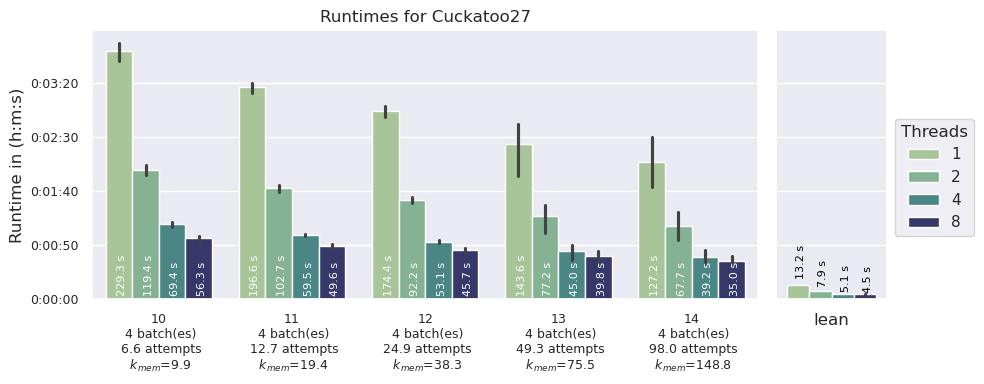

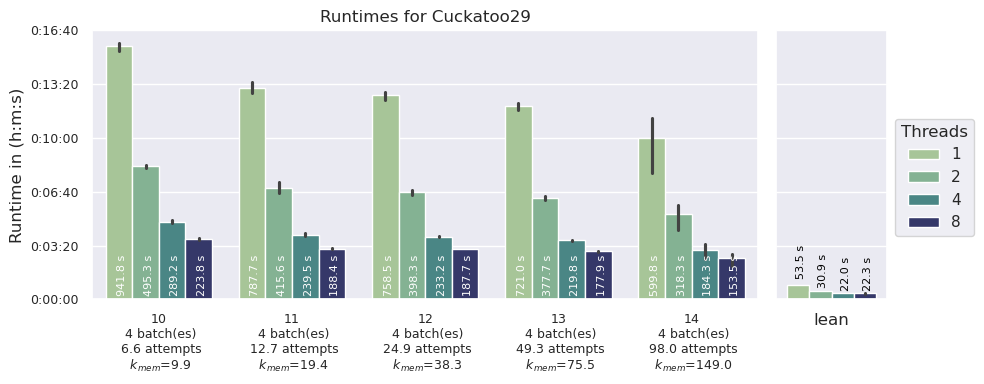

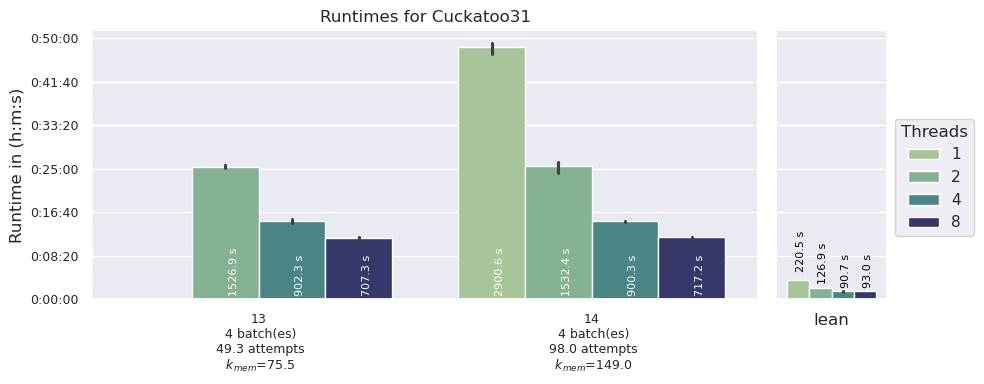

In [10]:
plot_eval_runtime(df, 27)
plot_eval_runtime(df, 29)
plot_eval_runtime(df, 31)

In [11]:
# function to plot the evaluation bar plot (plots relative speed ups)
def plot_eval_rel(df, edge_bits):
    # extract relevant data for this plot
    df2plt = df[df["EdgeBits"]==edge_bits]
    df2plt_agg = df2plt.groupby(['EdgeBits', 'kFactor']).agg({'MemoryFactor': ['mean', 'min', 'max', 'std']}).reset_index()
    df2plt_agg
    # plot data
    sns.set_theme()
    ax = sns.catplot(df2plt, kind="bar", x="kFactor", y="RelativeSpeedup", hue="Threads", errorbar=("pi", 100), palette="crest", legend_out=True, aspect = 1.5)
    # format title and axis labels
    ax.set(xlabel="", ylabel='Acceleration compared to 10$k_{mem}$ lean miner', title = "Results for Cuckatoo%i" % edge_bits)
    ax.set(ylim=(-0.5,2.5))
    ax.tick_params(axis='both', labelsize=10)
    # format y and x axis tick labels
    for a in ax.axes.flat:
        a.yaxis.set_major_formatter(FuncFormatter(lambda y, _: "+%.0f%%" % (y*100)))
        a.xaxis.set_major_formatter(FuncFormatter(lambda x, _: "%i\n $k_{mem}$= ~%.1f" % (df2plt_agg.iloc[[x]]["kFactor"].values[0], df2plt_agg.iloc[[x]]["MemoryFactor","mean"].values[0])))
    fig = ax.get_figure()
    fig.tight_layout()
    fig.savefig("splean2lean_%ibits.png" % edge_bits)
# function to plot the evaluation bar plot (plots equivalent timings)
def plot_eval_equi(df, edge_bits):
    # extract relevant data for this plot
    df2plt = df[df["EdgeBits"]==edge_bits]
    df2plt_agg = df2plt.groupby(['EdgeBits', 'kFactor']).agg({'MemoryFactor': ['mean', 'min', 'max', 'std']}).reset_index()
    df2plt_agg
    # plot data
    sns.set_theme()
    ax = sns.catplot(df2plt, kind="bar", x="kFactor", y="RelativeTimings", hue="Threads", errorbar=("pi", 100), palette="crest", legend_out=True, aspect = 1.5)
    # format title and axis labels
    ax.set(xlabel="", ylabel='Runtime compared to 10$k_{mem}$ lean miner', title = "Results for Cuckatoo%i" % edge_bits)
    ax.set(ylim=(0,2))
    ax.tick_params(axis='both', labelsize=10)
    ax.map(plt.axhline, y=1.0, ls='--', c='red')
    # format y and x axis tick labels
    for a in ax.axes.flat:
        #a.yaxis.set_major_formatter(FuncFormatter(lambda y, _: "+%.0f%%" % (y*100)))
        a.xaxis.set_major_formatter(FuncFormatter(lambda x, _: "%i\n $k_{mem}$= ~%.1f" % (df2plt_agg.iloc[[x]]["kFactor"].values[0], df2plt_agg.iloc[[x]]["MemoryFactor","mean"].values[0])))
    #fig = ax.get_figure()
    #fig.tight_layout()
    #fig.savefig("SpleanVsLean_Euqi_Cuckatoo%i.png" % edge_bits)
    plt.savefig("splean2lean_%ibits.png" % edge_bits)

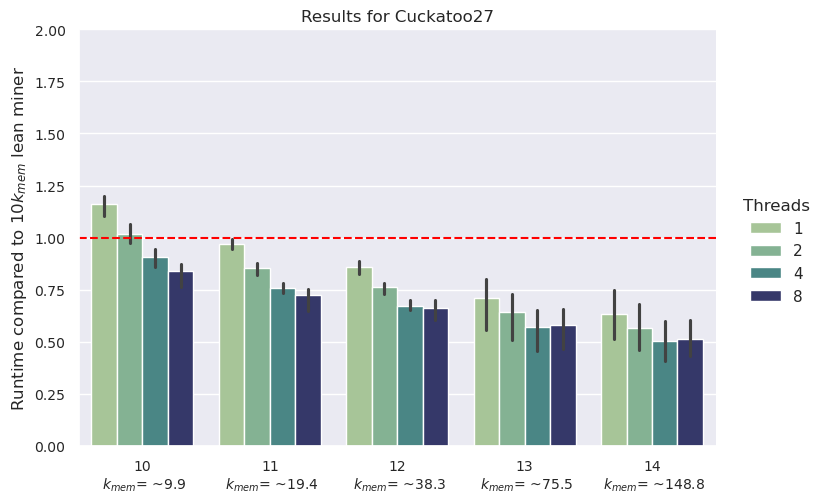

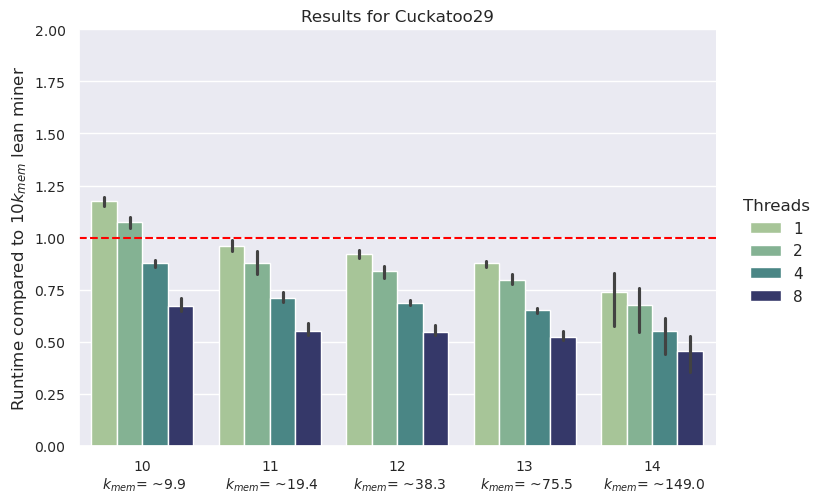

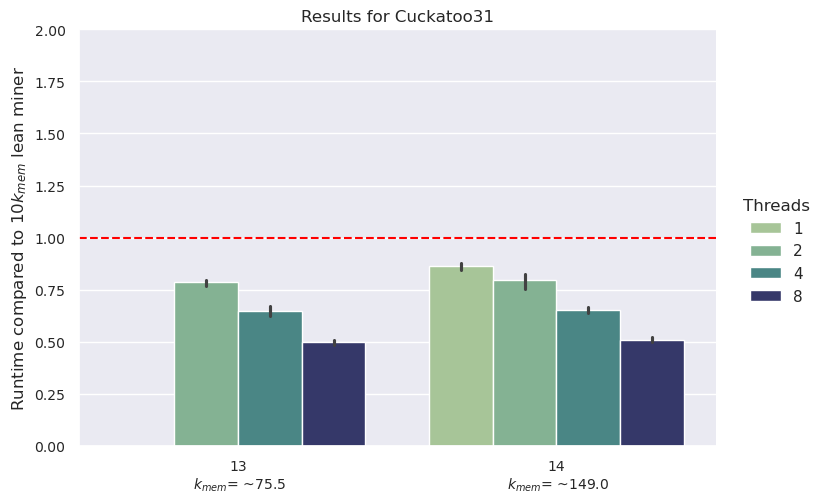

In [12]:
plot_eval_equi(df, 27)
plot_eval_equi(df, 29)
plot_eval_equi(df, 31)

In [13]:
# make overview table of evaluation setup
def print_overview_eval_setup(data): 
    tab = []
    for index, row in data.iterrows():
        #exec_filename = '_'.join(Path(row.Filename).stem.split('_')[:-1]) # recover executable filename from output filename, assumes naming is consistent
        mem_used_min = get_mem_str(row.MemoryBits['min']/8) # convert used memory in bits to readable human format
        mem_used_max = get_mem_str(row.MemoryBits['max']/8) # convert used memory in bits to readable human format
        mem_fact_min = 2**row.EdgeBits/(row.MemoryBits['min'])
        mem_fact_max = 2**row.EdgeBits/(row.MemoryBits['max'])
        tab.append("| Cuckatoo%i | 3, 0-4 | 1,2,4,8 | %i | %s - %s | %i | %.2f | %.2f - %.2f |" % (row.EdgeBits, row.kFactor, mem_used_min, mem_used_max, row.Batches, row.Attempts, mem_fact_min, mem_fact_max))
    
    print("|Variant   | Seeds, Nonces |Threads |k    |Memory used |Batches |Attempts  |$k_{mem}$ |") # printer header
    print("|:--------:|:-------------:|:------:|:---:|:----------:|:------:|:--------:|:--------:|")
    
    for row in tab: # print each line sorted
         print(row)

ov_df = df.groupby(['EdgeBits','kFactor']).agg({'MemoryBits':['min','max'], 'MemoryFactor':['min','max'], 'Batches':'first', 'Attempts':'first'}).reset_index()
print_overview_eval_setup(ov_df)


|Variant   | Seeds, Nonces |Threads |k    |Memory used |Batches |Attempts  |$k_{mem}$ |
|:--------:|:-------------:|:------:|:---:|:----------:|:------:|:--------:|:--------:|
| Cuckatoo27 | 3, 0-4 | 1,2,4,8 | 10 | 1.6 MiB - 1.6 MiB | 4 | 6.60 | 9.87 - 9.84 |
| Cuckatoo27 | 3, 0-4 | 1,2,4,8 | 11 | 842.1 KiB - 844.2 KiB | 4 | 12.69 | 19.46 - 19.41 |
| Cuckatoo27 | 3, 0-4 | 1,2,4,8 | 12 | 427.1 KiB - 428.2 KiB | 4 | 24.87 | 38.36 - 38.26 |
| Cuckatoo27 | 3, 0-4 | 1,2,4,8 | 13 | 216.6 KiB - 217.2 KiB | 4 | 49.25 | 75.64 - 75.43 |
| Cuckatoo27 | 3, 0-4 | 1,2,4,8 | 14 | 109.9 KiB - 110.2 KiB | 4 | 98.01 | 149.14 - 148.65 |
| Cuckatoo29 | 3, 0-4 | 1,2,4,8 | 10 | 6.5 MiB - 6.5 MiB | 4 | 6.60 | 9.87 - 9.85 |
| Cuckatoo29 | 3, 0-4 | 1,2,4,8 | 11 | 3.3 MiB - 3.3 MiB | 4 | 12.69 | 19.46 - 19.41 |
| Cuckatoo29 | 3, 0-4 | 1,2,4,8 | 12 | 1.7 MiB - 1.7 MiB | 4 | 24.87 | 38.37 - 38.28 |
| Cuckatoo29 | 3, 0-4 | 1,2,4,8 | 13 | 866.1 KiB - 868.2 KiB | 4 | 49.25 | 75.67 - 75.48 |
| Cuckatoo29 | 3, 0-4 | 1

/tmp/ipykernel_320669/3158597144.py:10: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  tab.append("| Cuckatoo%i | 3, 0-4 | 1,2,4,8 | %i | %s - %s | %i | %.2f | %.2f - %.2f |" % (row.EdgeBits, row.kFactor, mem_used_min, mem_used_max, row.Batches, row.Attempts, mem_fact_min, mem_fact_max))
/tmp/ipykernel_320669/3158597144.py:10: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  tab.append("| Cuckatoo%i | 3, 0-4 | 1,2,4,8 | %i | %s - %s | %i | %.2f | %.2f - %.2f |" % (row.EdgeBits, row.kFactor, mem_used_min, mem_used_max, row.Batches, row.Attempts, mem_fact_min, mem_fact_max))


In [14]:
# make full table of evaluation setup
def print_full_eval_setup(data):
    tab = []
    for index, row in data.iterrows():
        exec_filename = '_'.join(Path(row.Filename).stem.split('_')[:-1]) # recover executable filename from output filename, assumes naming is consistent
        mem_used = get_mem_str(row.MemoryBits/8) # convert used memory in bits to readable human format
        mem_fact = 2**row.EdgeBits/row.MemoryBits
        tab.append("| %s | %s | Cuckatoo%i | %s...%s | %i-%i | %i | %i | %s | %i | %.3f | %.3f |" % (exec_filename, row.Filename, row.EdgeBits, row.Seed[0:20], row.Seed[-5:-1], row.NonceStart, row.NonceStop, row.Threads, row.kFactor, mem_used, row.Batches, row.Attempts, mem_fact))
    print("|Exec. File |Output File |Variant   |Seed|Nonces |Threads |k  |Memory used |Batches |Attempts |$k_{mem}$ |") # printer header
    print("|-----------|------------|:--------:|:--:|:-----:|:------:|:-:|:----------:|:------:|:-------:|:--------:|")
    for row in sorted(tab): # print each line sorted
        print(row)

# make full table of baseline setup
def print_full_base_setup(data):
    tab = []
    for index, row in data.iterrows():
        exec_filename = '_'.join(Path(row.Filename).stem.split('_')[:-1]) # recover executable filename from output filename, assumes naming is consistent
        mem_used = get_mem_str(row.MemoryBits/8) # convert used memory in bits to readable human format
        mem_fact = 2**row.EdgeBits/(row.MemoryBits*2)
        tab.append("| %s | %s | Cuckatoo%i | %s...%s | %i-%i | %i | %s | %.3f |" % (exec_filename, row.Filename, row.EdgeBits, row.Seed[0:20], row.Seed[-5:-1], row.NonceStart, row.NonceStop, row.Threads, mem_used, mem_fact))
    print("|Exec. File |Output File |Variant   |Seed |Nonces |Threads |Memory used |$k_{mem}$ |") # printer header
    print("|-----------|------------|:--------:|:---:|:-----:|:------:|:----------:|:--------:|")
    for row in sorted(tab): # print each line sorted
        print(row)

print_full_eval_setup(pd.DataFrame(eval_data)) # print full table of the whole setup in MarkDown format
print("")
print_full_base_setup(pd.DataFrame(base_data))


|Exec. File |Output File |Variant   |Seed|Nonces |Threads |k  |Memory used |Batches |Attempts |$k_{mem}$ |
|-----------|------------|:--------:|:--:|:-----:|:------:|:-:|:----------:|:------:|:-------:|:--------:|
| splean27x8_k10_t1 | ../eval/data/splean27x8_k10_t1_seed0.out | Cuckatoo27 | 00000000000000000000...0000 | 0-3 | 1 | 10 | 1.6 MiB | 4 | 6.597 | 9.869 |
| splean27x8_k10_t1 | ../eval/data/splean27x8_k10_t1_seed1.out | Cuckatoo27 | 000005eed10000000000...0000 | 0-3 | 1 | 10 | 1.6 MiB | 4 | 6.597 | 9.869 |
| splean27x8_k10_t1 | ../eval/data/splean27x8_k10_t1_seed2.out | Cuckatoo27 | 00000000005eed200000...0000 | 0-3 | 1 | 10 | 1.6 MiB | 4 | 6.597 | 9.869 |
| splean27x8_k10_t2 | ../eval/data/splean27x8_k10_t2_seed0.out | Cuckatoo27 | 00000000000000000000...0000 | 0-3 | 2 | 10 | 1.6 MiB | 4 | 6.597 | 9.845 |
| splean27x8_k10_t2 | ../eval/data/splean27x8_k10_t2_seed1.out | Cuckatoo27 | 000005eed10000000000...0000 | 0-3 | 2 | 10 | 1.6 MiB | 4 | 6.597 | 9.845 |
| splean27x8_k10_t2 |